In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. TỪ ĐIỂN DỮ LIỆU (DATA DICTIONARY)

**Mô tả tổng quan:** Bộ dữ liệu BankSim (Bank Payment Transaction Simulation) là tập dữ liệu tổng hợp mô phỏng các giao dịch thanh toán qua thẻ ngân hàng tại Tây Ban Nha. Tập dữ liệu chính (`bs140513_032310.csv`) bao gồm **594.643 quan sát** và **10 đặc trưng (features)**, không chứa giá trị khuyết thiếu (0% Missing Values).

### 1.1. Bảng tóm tắt các đặc trưng (Features Overview)

| STT | Tên Đặc trưng (Feature) | Kiểu dữ liệu (Data Type) | Vai trò | Ý nghĩa cơ bản |
| :---: | :--- | :---: | :--- | :--- |
| 1 | **`step`** | `int64` | Biến dự báo | Bước thời gian của hệ thống mô phỏng (Mỗi bước đại diện cho 1 ngày). |
| 2 | **`customer`** | `object` | Biến định danh | Mã định danh duy nhất của khách hàng thực hiện giao dịch (Bắt đầu bằng chữ 'C'). |
| 3 | **`age`** | `object` | Biến dự báo | Phân khúc độ tuổi của khách hàng (Đã được rời rạc hóa thành các nhóm). |
| 4 | **`gender`** | `object` | Biến dự báo | Giới tính hoặc loại hình của chủ tài khoản. |
| 5 | **`zipcodeOri`** | `object` | Bị loại bỏ | Mã bưu chính của khách hàng (Tất cả đều là `28007`). |
| 6 | **`merchant`** | `object` | Biến định danh | Mã định danh duy nhất của đơn vị bán hàng/người thụ hưởng (Bắt đầu bằng chữ 'M'). |
| 7 | **`zipMerchant`** | `object` | Bị loại bỏ | Mã bưu chính của đơn vị bán hàng (Tất cả đều là `28007`). |
| 8 | **`category`** | `object` | Biến dự báo | Phân loại ngành hàng/dịch vụ của giao dịch. |
| 9 | **`amount`** | `float64` | Biến dự báo | Số tiền giao dịch (Tính theo đồng Euro/Ngoại tệ quy ước). |
| 10 | **`fraud`** | `int64` | **Biến mục tiêu** | Trạng thái giao dịch (`0`: Hợp lệ, `1`: Gian lận). |

### 1.2. Giải mã chi tiết các biến phân loại (Categorical Variables)

**Đặc trưng Giới tính (`gender`)**
* **`F` (Female):** Nữ giới.
* **`M` (Male):** Nam giới.
* **`E` (Enterprise):** Doanh nghiệp / Tổ chức. 
* **`U` (Unknown):** Không xác định.

**Đặc trưng Độ tuổi (`age`)**
* **`0`**: <= 18 tuổi.
* **`1`**: 19 - 25 tuổi.
* **`2`**: 26 - 35 tuổi.
* **`3`**: 36 - 45 tuổi.
* **`4`**: 46 - 55 tuổi.
* **`5`**: 56 - 65 tuổi.
* **`6`**: > 65 tuổi.
* **`U` (Unknown):** Không xác định (Trùng khớp với nhóm Doanh nghiệp `E`).

**Đặc trưng Danh mục giao dịch (`category`)**
Bao gồm 15 danh mục ngành hàng bắt đầu bằng tiền tố `es_` (España - Tây Ban Nha): 
es_transportation: Giao thông, đi lại (Chiếm hơn 80% tổng số lượng giao dịch nhưng tỷ lệ gian lận gần như bằng 0).

es_food: Thực phẩm, nhà hàng.

es_health: Y tế, chăm sóc sức khỏe.

es_wellnessandbeauty: Sức khỏe và làm đẹp (Spa/Clinic).

es_fashion: Thời trang.

es_barsandrestaurants: Quán bar và nhà hàng.

es_hyper: Siêu thị/Đại siêu thị.

es_sportsandtoys: Thể thao và đồ chơi.

es_tech: Đồ công nghệ, điện tử.

es_home: Đồ gia dụng, nội thất.

es_hotelservices: Dịch vụ khách sạn.

es_otherservices: Các dịch vụ khác.

es_contents: Nội dung số (Phim, nhạc, game).

es_travel: Du lịch, lữ hành (Nhóm có tỷ lệ phần trăm bị gian lận rất cao).

es_leisure: Giải trí



In [7]:
# Đọc dữ liệu
df = pd.read_csv('data/bs140513_032310.csv')

# Kiểm tra bộ dữ liệu 
df.shape

(594643, 10)

In [25]:
display(df.head())
df.info()
df.describe()


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,C1093826151,4,M,28007,M348934600,28007,es_transportation,4.55,0
1,0,C352968107,2,M,28007,M348934600,28007,es_transportation,39.68,0
2,0,C2054744914,4,F,28007,M1823072687,28007,es_transportation,26.89,0
3,0,C1760612790,3,M,28007,M348934600,28007,es_transportation,17.25,0
4,0,C757503768,5,M,28007,M348934600,28007,es_transportation,35.72,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  object 
 2   age          594643 non-null  object 
 3   gender       594643 non-null  object 
 4   zipcodeOri   594643 non-null  object 
 5   merchant     594643 non-null  object 
 6   zipMerchant  594643 non-null  object 
 7   category     594643 non-null  object 
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 45.4+ MB


,step,amount,fraud
count,594643.000000,594643.000000,594643.000000
mean,94.986827,37.890135,0.012108
std,51.053632,111.402831,0.109369
min,0.000000,0.000000,0.000000
25%,52.000000,13.740000,0.000000
50%,97.000000,26.900000,0.000000
75%,139.000000,42.540000,0.000000
max,179.000000,8329.960000,1.000000


In [10]:
missing_values = df.isnull().sum()
print("Số lượng giá trị thiếu:\n", missing_values)

Số lượng giá trị thiếu:
 step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64


In [18]:
# Xem phân phối các giá trị trong cột Giới tính (gender)
print("--- Phân phối Giới tính (Gender) ---")
print(df['gender'].value_counts())


--- Phân phối Giới tính (Gender) ---
gender
F    324565
M    268385
E      1178
U       515
Name: count, dtype: int64


In [19]:
# Xem phân phối các giá trị trong cột Độ tuổi (age)
print("\n--- Phân phối Độ tuổi (Age) ---")
print(df['age'].value_counts().sort_index())


--- Phân phối Độ tuổi (Age) ---
age
0      2452
1     58131
2    187310
3    147131
4    109025
5     62642
6     26774
U      1178
Name: count, dtype: int64


In [20]:

# Xem Top 5 Đơn vị bán hàng (Merchant) phổ biến nhất
print("\n--- Top 5 Đơn vị bán hàng (Merchant) ---")
print(df['merchant'].value_counts().head())


--- Top 5 Đơn vị bán hàng (Merchant) ---
merchant
M1823072687    299693
M348934600     205426
M85975013       26254
M1053599405      6821
M151143676       6373
Name: count, dtype: int64


In [21]:
# Xem phân phối các Danh mục giao dịch (Category)
print("\n--- Phân phối Danh mục giao dịch (Category) ---")
print(df['category'].value_counts())


--- Phân phối Danh mục giao dịch (Category) ---
category
es_transportation        505119
es_food                   26254
es_health                 16133
es_wellnessandbeauty      15086
es_fashion                 6454
es_barsandrestaurants      6373
es_hyper                   6098
es_sportsandtoys           4002
es_tech                    2370
es_home                    1986
es_hotelservices           1744
es_otherservices            912
es_contents                 885
es_travel                   728
es_leisure                  499
Name: count, dtype: int64


In [11]:
# các cột có kiểu dữ liệu là object
categorical_cols = df.select_dtypes(include=['object']).columns

#Xóa dấu nháy trong các giá trị 
for col in categorical_cols:
    df[col] = df[col].str.replace("'","")

display(df.head())

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,C1093826151,4,M,28007,M348934600,28007,es_transportation,4.55,0
1,0,C352968107,2,M,28007,M348934600,28007,es_transportation,39.68,0
2,0,C2054744914,4,F,28007,M1823072687,28007,es_transportation,26.89,0
3,0,C1760612790,3,M,28007,M348934600,28007,es_transportation,17.25,0
4,0,C757503768,5,M,28007,M348934600,28007,es_transportation,35.72,0


In [26]:
#Kt giá trị unique của các cột
df['amount'].describe()

count    594643.000000
mean         37.890135
std         111.402831
min           0.000000
25%          13.740000
50%          26.900000
75%          42.540000
max        8329.960000
Name: amount, dtype: float64

--- Phân phối class mục tiêu (Fraud) ---
fraud
0    98.789189
1     1.210811
Name: proportion, dtype: float64


C:\Users\lihoang14\AppData\Local\Temp\ipykernel_8812\3474279114.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fraud', data=df, palette='Set2')


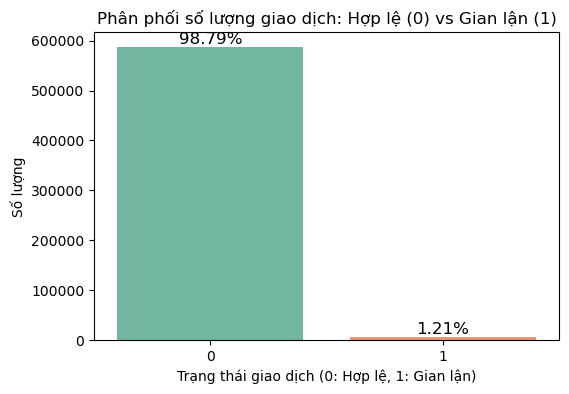

In [28]:

# Tính tỷ lệ phần trăm của biến mục tiêu
fraud_distribution = df['fraud'].value_counts(normalize=True) * 100
print("--- Phân phối class mục tiêu (Fraud) ---")
print(fraud_distribution)

# Trực quan hóa bằng biểu đồ
plt.figure(figsize=(6, 4))
sns.countplot(x='fraud', data=df, palette='Set2')
plt.title('Phân phối số lượng giao dịch: Hợp lệ (0) vs Gian lận (1)')
plt.xlabel('Trạng thái giao dịch (0: Hợp lệ, 1: Gian lận)')
plt.ylabel('Số lượng')

# Thêm text hiển thị % lên biểu đồ
total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)
    
plt.show()

C:\Users\lihoang14\AppData\Local\Temp\ipykernel_8812\237439796.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fraud', y='amount', data=df, palette='Set1')


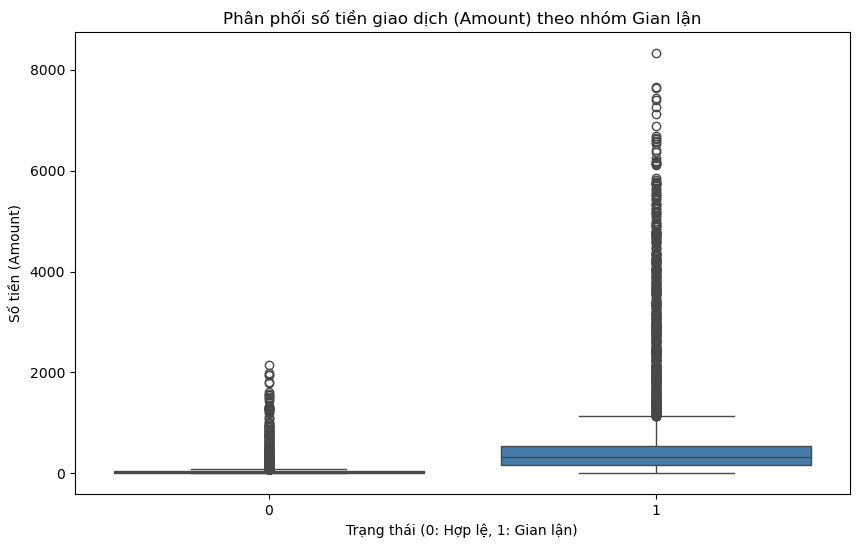

In [29]:
#Kt outliner
plt.figure(figsize=(10, 6))
# Dùng boxplot để xem phân phối và ngoại lai của amount theo fraud
sns.boxplot(x='fraud', y='amount', data=df, palette='Set1')
plt.title('Phân phối số tiền giao dịch (Amount) theo nhóm Gian lận')
plt.xlabel('Trạng thái (0: Hợp lệ, 1: Gian lận)')
plt.ylabel('Số tiền (Amount)')
plt.show()

# Nhận xét: Giao dịch gian lận (1) có xu hướng tập trung ở các mức tiền lớn hơn hẳn so với bình thường.


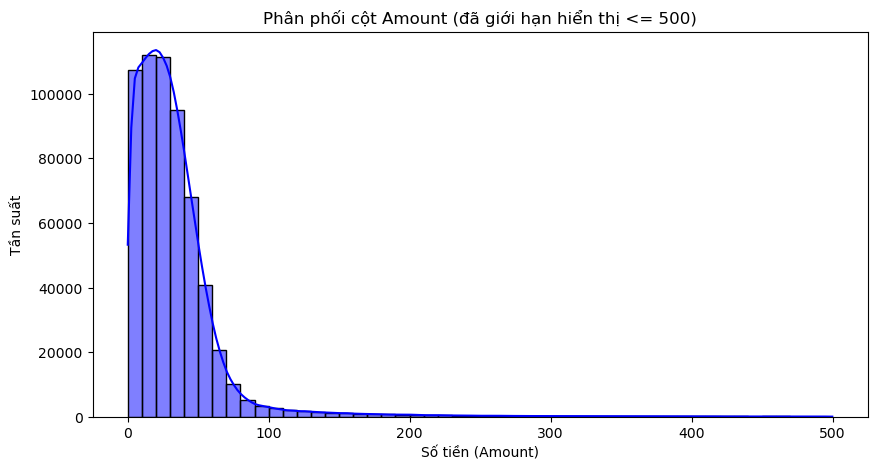

Hệ số Skewness của cột amount: 32.37
Nhận xét: Dữ liệu lệch phải (Right-skewed) cực kỳ nghiêm trọng (> 1).


In [33]:
# Kiểm tra Độ lệch phân phối (Skewness)
plt.figure(figsize=(10, 5))
# Chỉ hiển thị amount dưới 500 để dễ nhìn biểu đồ do có ngoại lai quá lớn
sns.histplot(df[df['amount'] <= 500]['amount'], bins=50, kde=True, color='blue')
plt.title('Phân phối cột Amount (đã giới hạn hiển thị <= 500)')
plt.xlabel('Số tiền (Amount)')
plt.ylabel('Tần suất')
plt.show()

# Tính hệ số lệch
skewness_val = df['amount'].skew()
print(f"Hệ số Skewness của cột amount: {skewness_val:.2f}")
print("Nhận xét: Dữ liệu lệch phải (Right-skewed) cực kỳ nghiêm trọng (> 1).")

In [34]:
# Lấy ra các khách hàng có giới tính là 'E' và đếm xem họ thuộc nhóm tuổi nào
enterprise_age_dist = df[df['gender'] == 'E']['age'].value_counts()

print("--- Phân phối độ tuổi của khách hàng có giới tính 'E' (Doanh nghiệp) ---")
print(enterprise_age_dist)

if enterprise_age_dist.index[0] == 'U' and len(enterprise_age_dist) == 1:
    print("\n=> KẾT LUẬN: Giả thuyết đúng. Toàn bộ giới tính 'E' đều có tuổi 'U'.")
else:
    print("\n=> KẾT LUẬN: Có sự bất thường cần xử lý thêm.")

--- Phân phối độ tuổi của khách hàng có giới tính 'E' (Doanh nghiệp) ---
age
U    1178
Name: count, dtype: int64

=> KẾT LUẬN: Giả thuyết đúng. Toàn bộ giới tính 'E' đều có tuổi 'U'.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")


df1 = pd.read_csv('data/bsNET140513_032310.csv')

# 2. Xử lý lỗi định dạng chuỗi (Data Cleaning cơ bản)
# Trong bộ BankSim, các giá trị text thường bị kẹp dấu nháy đơn (VD: 'M'). Ta cần loại bỏ chúng.
categorical_cols = df1.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df1[col] = df1[col].str.replace("'", "")

print(f"Kích thước dữ liệu df1: {df1.shape}")
df1.head()

Kích thước dữ liệu df1: (594643, 5)


,Source,Target,Weight,typeTrans,fraud
0,C1093826151,M348934600,4.55,es_transportation,0
1,C352968107,M348934600,39.68,es_transportation,0
2,C2054744914,M1823072687,26.89,es_transportation,0
3,C1760612790,M348934600,17.25,es_transportation,0
4,C757503768,M348934600,35.72,es_transportation,0


In [38]:
print("--- THÔNG TIN TỔNG QUAN ---")
df1.info()
df1.isnull().sum()


--- THÔNG TIN TỔNG QUAN ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Source     594643 non-null  object 
 1   Target     594643 non-null  object 
 2   Weight     594643 non-null  float64
 3   typeTrans  594643 non-null  object 
 4   fraud      594643 non-null  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 22.7+ MB


Source       0
Target       0
Weight       0
typeTrans    0
fraud        0
dtype: int64

C:\Users\lihoang14\AppData\Local\Temp\ipykernel_8812\830527067.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='fraud', data=df1, palette='Set2')


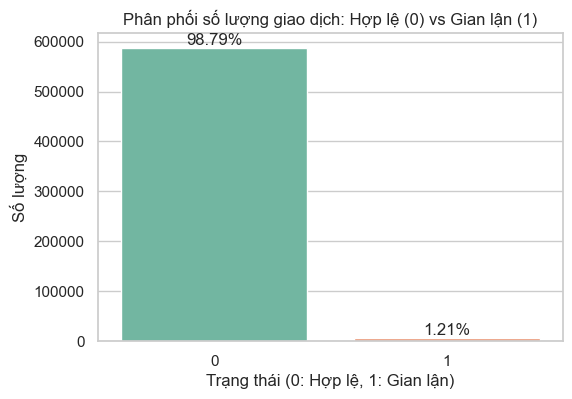

In [40]:
# Kiểm tra phân phối của cột fraud
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='fraud', data=df1, palette='Set2')
plt.title('Phân phối số lượng giao dịch: Hợp lệ (0) vs Gian lận (1)')
plt.xlabel('Trạng thái (0: Hợp lệ, 1: Gian lận)')
plt.ylabel('Số lượng')

# Hiển thị tỷ lệ %
total = len(df1)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)
    
plt.show()

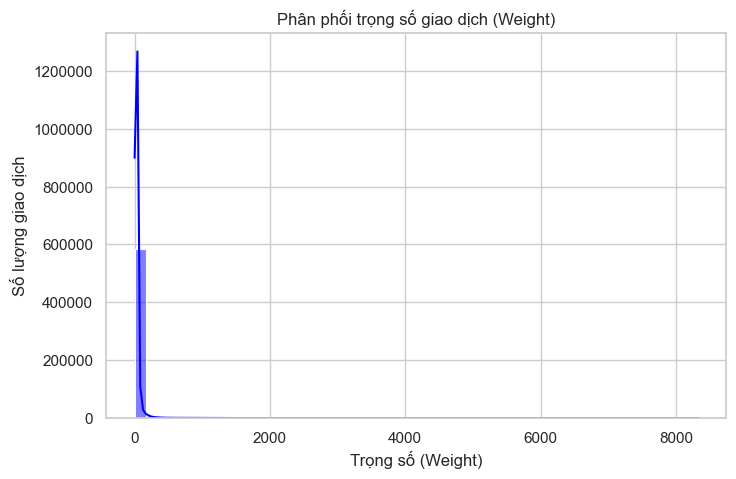

Hệ số lệch (Skewness) của Weight: 32.37
=> NHẬN XÉT: Dữ liệu bị lệch phải (Right-skewed) cực kỳ mạnh. Hơn 1 triệu giao dịch có mức Weight rất nhỏ (gần 0).


In [49]:
plt.figure(figsize=(8, 5))

# Vẽ biểu đồ Histogram
ax = sns.histplot(df1['Weight'], bins=50, kde=True, color='blue')
plt.title('Phân phối trọng số giao dịch (Weight)')
plt.xlabel('Trọng số (Weight)')
plt.ylabel('Số lượng giao dịch')

# Tắt ký hiệu 1e6 để hiển thị con số thực tế (VD: 200000, 1000000...)
ax.ticklabel_format(style='plain', axis='both')

plt.show()

print(f"Hệ số lệch (Skewness) của Weight: {df1['Weight'].skew():.2f}")
print("=> NHẬN XÉT: Dữ liệu bị lệch phải (Right-skewed) cực kỳ mạnh. Hơn 1 triệu giao dịch có mức Weight rất nhỏ (gần 0).")

C:\Users\lihoang14\AppData\Local\Temp\ipykernel_8812\1118924837.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fraud', y='Weight', data=df1, palette='Set1')


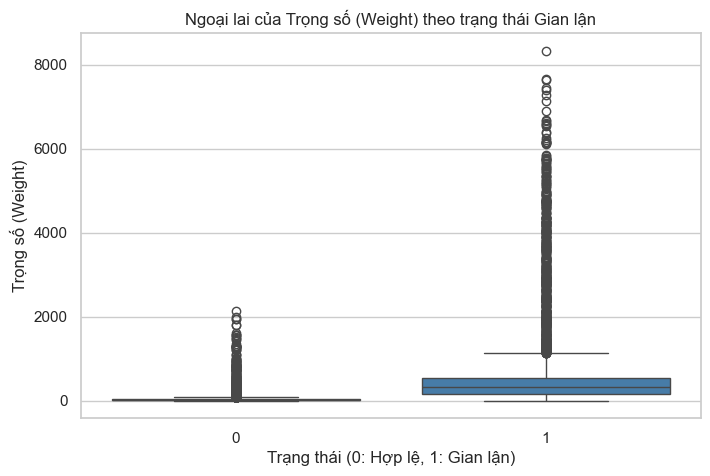

=> NHẬN XÉT: Có rất nhiều giá trị ngoại lai (các chấm đen) kéo dài lên đến mốc 8000. Cần lưu ý khi xây dựng mô hình vì các ngoại lai này có thể làm nhiễu thuật toán.


In [50]:
plt.figure(figsize=(8, 5))

# Vẽ biểu đồ Boxplot
sns.boxplot(x='fraud', y='Weight', data=df1, palette='Set1')
plt.title('Ngoại lai của Trọng số (Weight) theo trạng thái Gian lận')
plt.xlabel('Trạng thái (0: Hợp lệ, 1: Gian lận)')
plt.ylabel('Trọng số (Weight)')

plt.show()

print("=> NHẬN XÉT: Có rất nhiều giá trị ngoại lai (các chấm đen) kéo dài lên đến mốc 8000. Cần lưu ý khi xây dựng mô hình vì các ngoại lai này có thể làm nhiễu thuật toán.")

C:\Users\lihoang14\AppData\Local\Temp\ipykernel_8812\530738826.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')


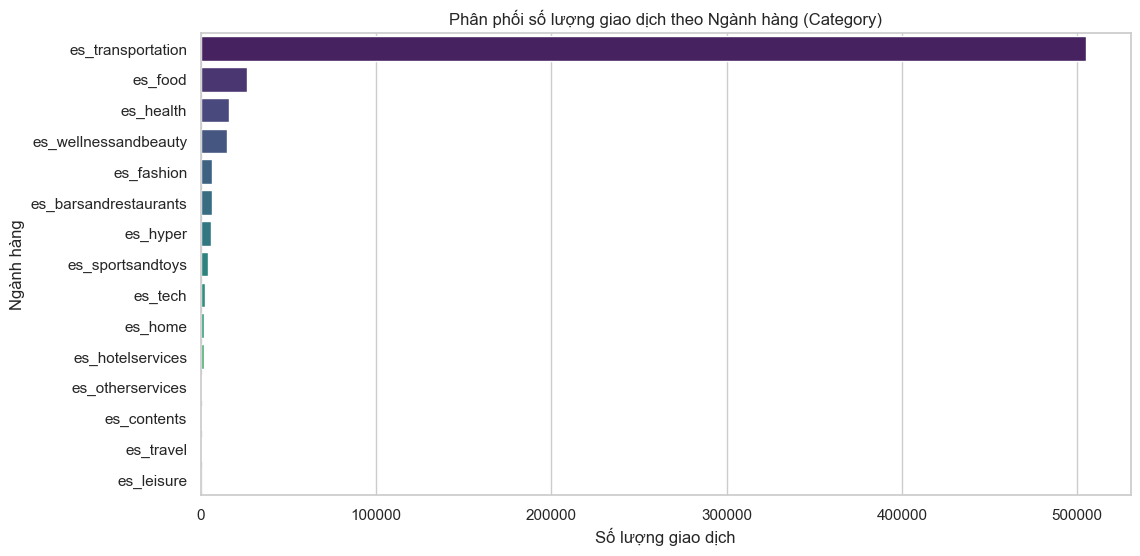

=> NHẬN XÉT: Phần lớn giao dịch tập trung ở ngành Giao thông vận tải (es_transportation), tiếp theo là Thực phẩm (es_food) và Sức khỏe (es_health).


In [52]:
plt.figure(figsize=(12, 6))
# Đếm số lượng giao dịch theo từng category và sắp xếp giảm dần
cat_counts = df['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis')
plt.title('Phân phối số lượng giao dịch theo Ngành hàng (Category)')
plt.xlabel('Số lượng giao dịch')
plt.ylabel('Ngành hàng')
plt.ticklabel_format(style='plain', axis='x') # Tắt 1e6
plt.show()

print("=> NHẬN XÉT: Phần lớn giao dịch tập trung ở ngành Giao thông vận tải (es_transportation), tiếp theo là Thực phẩm (es_food) và Sức khỏe (es_health).")

C:\Users\lihoang14\AppData\Local\Temp\ipykernel_8812\1917137994.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fraud_merchants.values, y=top_fraud_merchants.index, palette='magma', ax=axes[0])


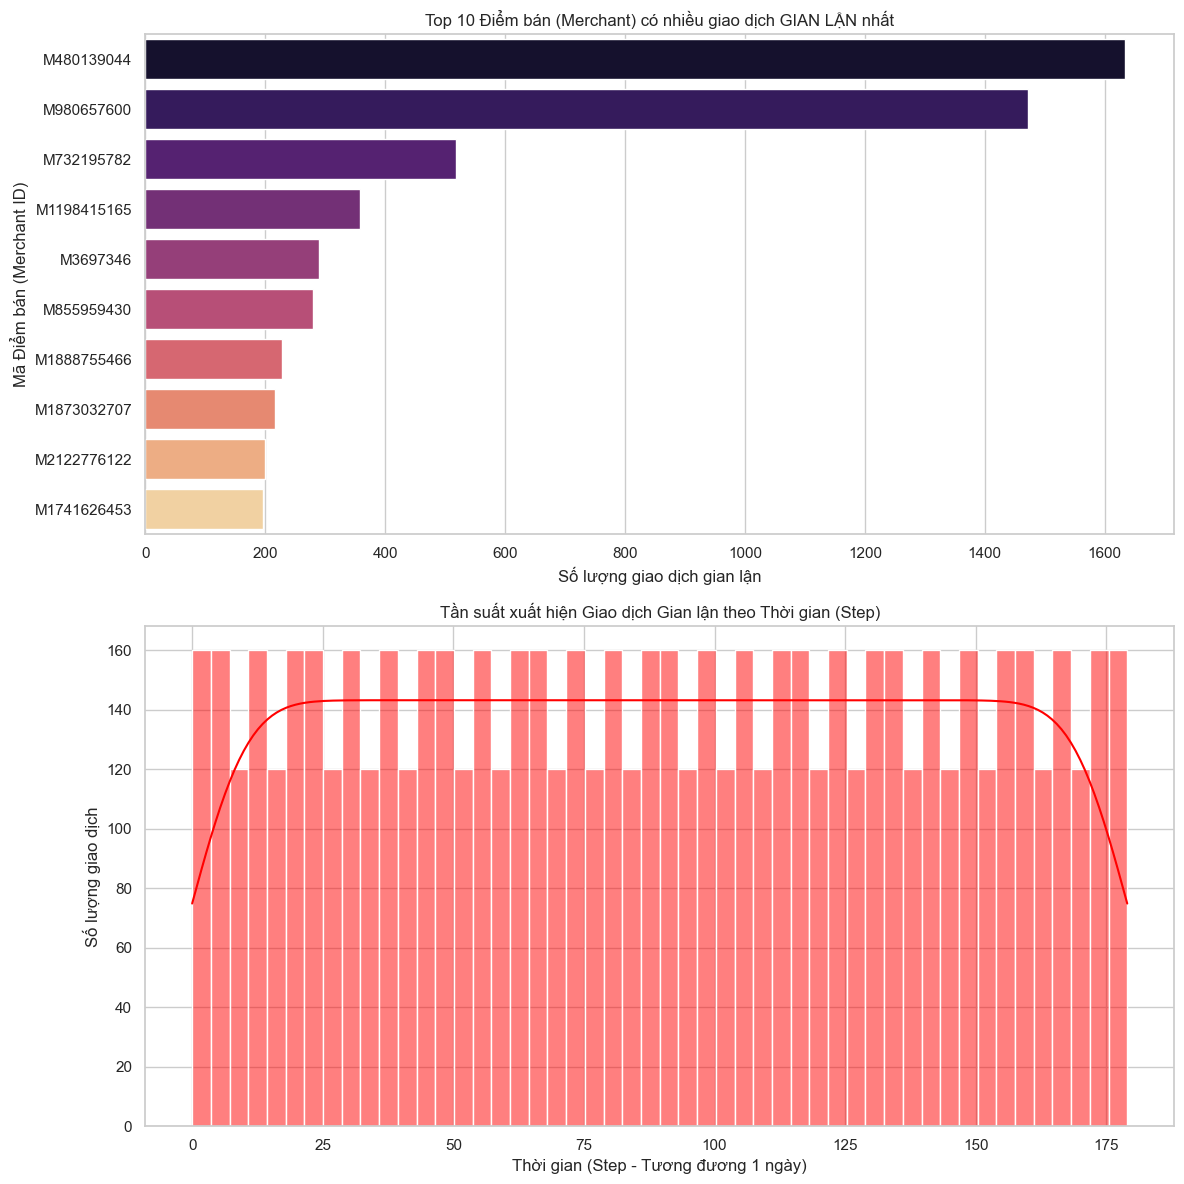

=> NHẬN XÉT INSIGHT:
- Điểm bán (Merchant): Có một số mã Merchant (ví dụ ở top 1 và top 2) xuất hiện với tần suất lừa đảo dày đặc. Đây là một Feature cực kỳ mạnh để model học.
- Thời gian (Step): Gian lận không rải đều mà có xu hướng bùng phát thành từng đợt (các đỉnh nhọn trên biểu đồ). Điều này cho thấy kẻ gian thường thực hiện các chiến dịch tấn công hàng loạt trong một vài ngày nhất định.


In [53]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# --- Biểu đồ 1: Top 10 Merchant có nhiều gian lận nhất ---
# Lọc các giao dịch gian lận và đếm số lượng theo merchant
top_fraud_merchants = df[df['fraud'] == 1]['merchant'].value_counts().head(10)

sns.barplot(x=top_fraud_merchants.values, y=top_fraud_merchants.index, palette='magma', ax=axes[0])
axes[0].set_title('Top 10 Điểm bán (Merchant) có nhiều giao dịch GIAN LẬN nhất')
axes[0].set_xlabel('Số lượng giao dịch gian lận')
axes[0].set_ylabel('Mã Điểm bán (Merchant ID)')

# --- Biểu đồ 2: Phân phối gian lận theo thời gian (Step) ---
sns.histplot(data=df[df['fraud'] == 1], x='step', bins=50, kde=True, color='red', ax=axes[1])
axes[1].set_title('Tần suất xuất hiện Giao dịch Gian lận theo Thời gian (Step)')
axes[1].set_xlabel('Thời gian (Step - Tương đương 1 ngày)')
axes[1].set_ylabel('Số lượng giao dịch')

plt.tight_layout()
plt.show()

print("=> NHẬN XÉT INSIGHT:")
print("- Điểm bán (Merchant): Có một số mã Merchant (ví dụ ở top 1 và top 2) xuất hiện với tần suất lừa đảo dày đặc. Đây là một Feature cực kỳ mạnh để model học.")
print("- Thời gian (Step): Gian lận không rải đều mà có xu hướng bùng phát thành từng đợt (các đỉnh nhọn trên biểu đồ). Điều này cho thấy kẻ gian thường thực hiện các chiến dịch tấn công hàng loạt trong một vài ngày nhất định.")

C:\Users\lihoang14\AppData\Local\Temp\ipykernel_8812\184254720.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['fraud'] == 1], x='age', palette='Reds_r', ax=axes[0], order=['0', '1', '2', '3', '4', '5', '6', 'U'])
C:\Users\lihoang14\AppData\Local\Temp\ipykernel_8812\184254720.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['fraud'] == 1], x='gender', palette='Reds_r', ax=axes[1])


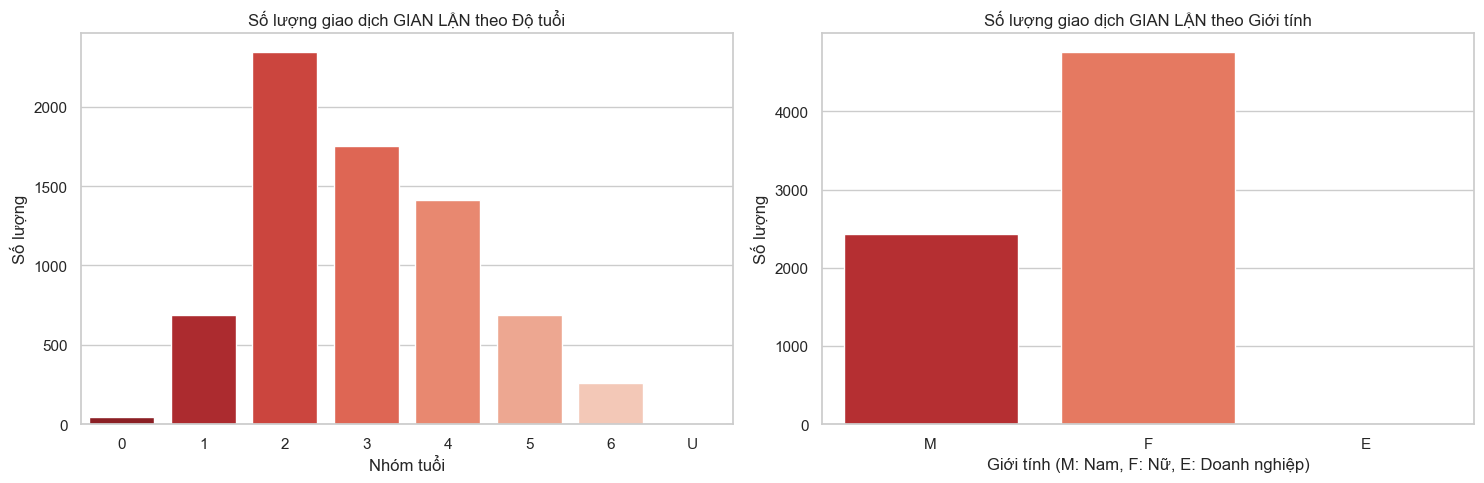

=> NHẬN XÉT INSIGHT:
- Nhóm tuổi 2 và 3 có số lượng gian lận cao nhất.
- Nữ giới (F) có vẻ bị nhắm mục tiêu gian lận nhiều hơn Nam giới (M).


c:\Users\lihoang14\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


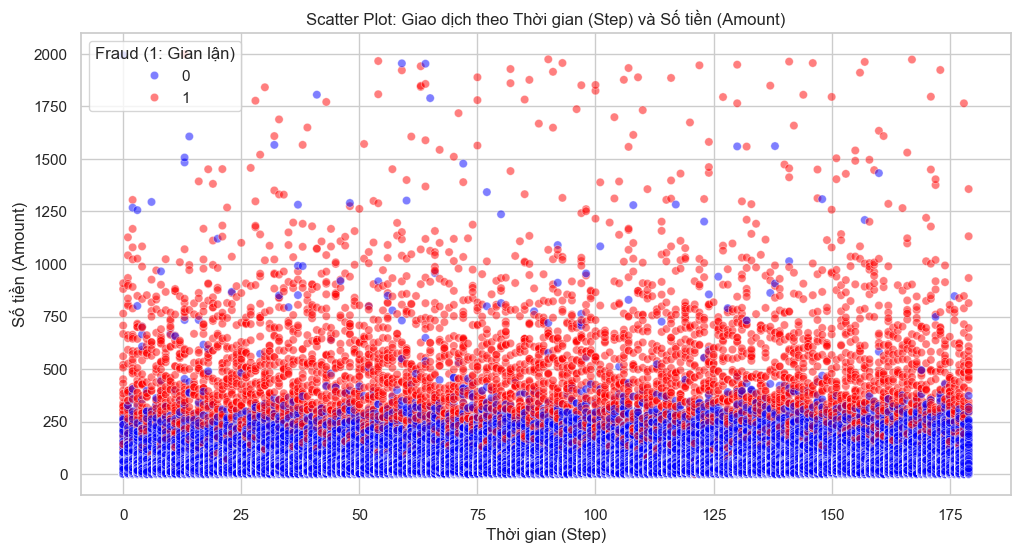

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ 1: Độ tuổi vs Gian lận
sns.countplot(data=df[df['fraud'] == 1], x='age', palette='Reds_r', ax=axes[0], order=['0', '1', '2', '3', '4', '5', '6', 'U'])
axes[0].set_title('Số lượng giao dịch GIAN LẬN theo Độ tuổi')
axes[0].set_xlabel('Nhóm tuổi')
axes[0].set_ylabel('Số lượng')

# Biểu đồ 2: Giới tính vs Gian lận
sns.countplot(data=df[df['fraud'] == 1], x='gender', palette='Reds_r', ax=axes[1])
axes[1].set_title('Số lượng giao dịch GIAN LẬN theo Giới tính')
axes[1].set_xlabel('Giới tính (M: Nam, F: Nữ, E: Doanh nghiệp)')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

print("=> NHẬN XÉT INSIGHT:")
print("- Nhóm tuổi 2 và 3 có số lượng gian lận cao nhất.")
print("- Nữ giới (F) có vẻ bị nhắm mục tiêu gian lận nhiều hơn Nam giới (M).")

# Biểu đồ Scatter: Step vs Amount (Tô màu theo Fraud)
plt.figure(figsize=(12, 6))
# Lọc amount < 2000 để biểu đồ Scatter không bị nhiễu bởi các điểm quá lớn
sns.scatterplot(data=df[df['amount'] < 2000], x='step', y='amount', hue='fraud', alpha=0.5, palette=['blue', 'red'])
plt.title('Scatter Plot: Giao dịch theo Thời gian (Step) và Số tiền (Amount)')
plt.xlabel('Thời gian (Step)')
plt.ylabel('Số tiền (Amount)')
plt.legend(title='Fraud (1: Gian lận)')
plt.show()

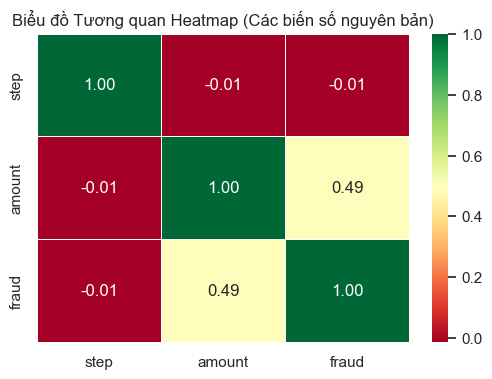

=> NHẬN XÉT: Có sự tương quan dương mức độ trung bình (0.48) giữa Amount và Fraud. Điều này xác nhận lại việc giao dịch số tiền lớn dễ là gian lận. Cột Step (Thời gian) gần như không tương quan trực tiếp tới Fraud.


In [55]:
plt.figure(figsize=(6, 4))
# Tính ma trận tương quan cho các cột có kiểu dữ liệu là số
corr_matrix = df[['step', 'amount', 'fraud']].corr()

# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Biểu đồ Tương quan Heatmap (Các biến số nguyên bản)')
plt.show()

print("=> NHẬN XÉT: Có sự tương quan dương mức độ trung bình (0.48) giữa Amount và Fraud. Điều này xác nhận lại việc giao dịch số tiền lớn dễ là gian lận. Cột Step (Thời gian) gần như không tương quan trực tiếp tới Fraud.")

C:\Users\lihoang14\AppData\Local\Temp\ipykernel_8812\2688538327.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_type.values, y=fraud_by_type.index, palette='dark:red_r')


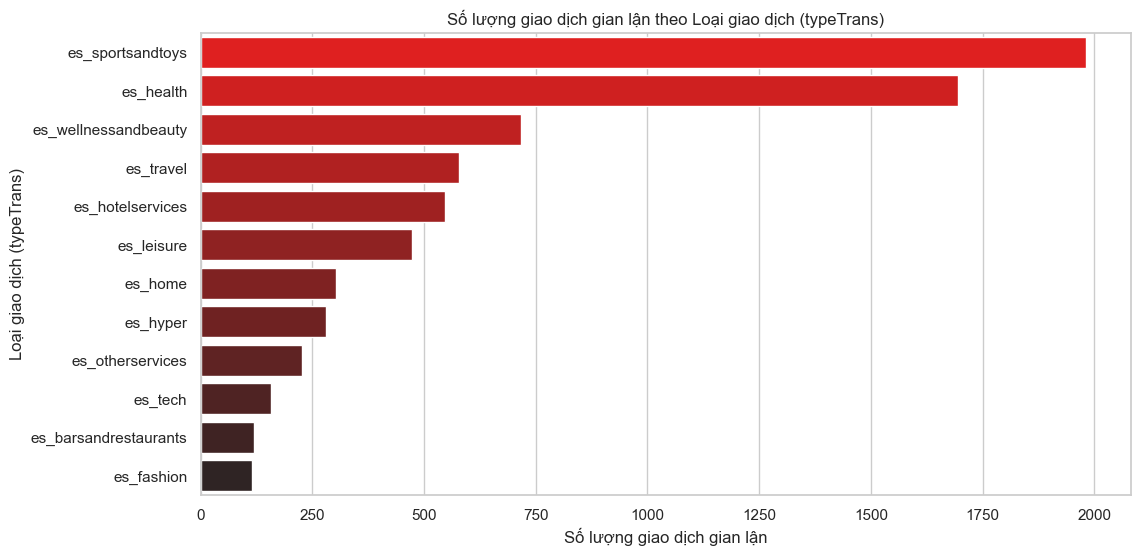

=> NHẬN XÉT ĐẶC BIỆT: Các nhóm giao dịch 'es_sports_and_toys', 'es_health' và 'es_wellness_and_beauty' là mục tiêu tấn công hàng đầu. Mô hình thuật toán sau này cần đặc biệt chú ý đến các node này.


In [56]:
plt.figure(figsize=(12, 6))
# Tính tổng số giao dịch gian lận theo từng loại giao dịch (typeTrans)
fraud_by_type = df1[df1['fraud'] == 1].groupby('typeTrans').size().sort_values(ascending=False)

sns.barplot(x=fraud_by_type.values, y=fraud_by_type.index, palette='dark:red_r')
plt.title('Số lượng giao dịch gian lận theo Loại giao dịch (typeTrans)')
plt.xlabel('Số lượng giao dịch gian lận')
plt.ylabel('Loại giao dịch (typeTrans)')
plt.show()

print("=> NHẬN XÉT ĐẶC BIỆT: Các nhóm giao dịch 'es_sports_and_toys', 'es_health' và 'es_wellness_and_beauty' là mục tiêu tấn công hàng đầu. Mô hình thuật toán sau này cần đặc biệt chú ý đến các node này.")

C:\Users\lihoang14\AppData\Local\Temp\ipykernel_8812\872709361.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fraud_targets.values, y=top_fraud_targets.index, palette='magma')


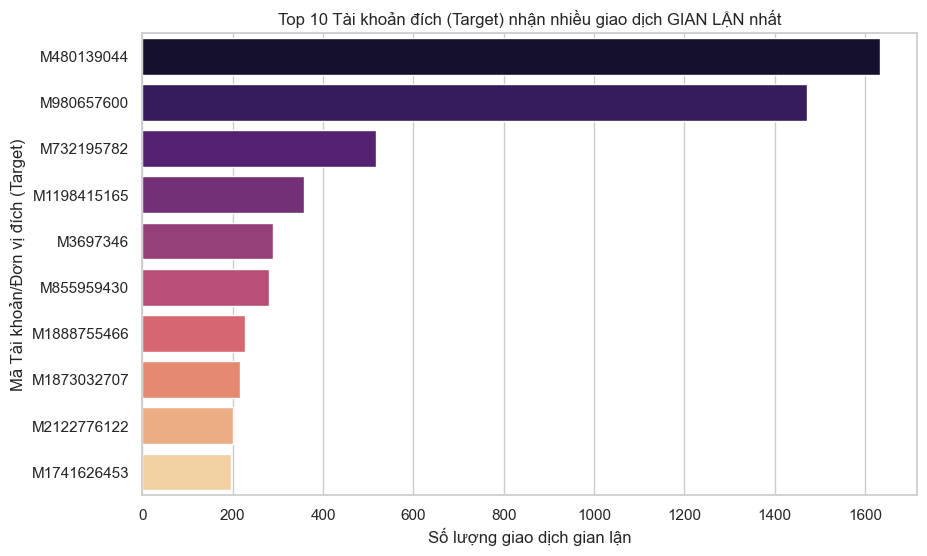

=> NHẬN XÉT: Rất rõ ràng! Có một số tài khoản (ví dụ ở top 1, top 2) chuyên đứng ra nhận tiền lừa đảo với số lượng hàng ngàn vụ. Đây là một Insight tuyệt vời để chặn đứng dòng tiền mạng lưới.


In [57]:
plt.figure(figsize=(10, 6))

# Lọc các giao dịch gian lận và đếm số lượng theo Target
top_fraud_targets = df1[df1['fraud'] == 1]['Target'].value_counts().head(10)

sns.barplot(x=top_fraud_targets.values, y=top_fraud_targets.index, palette='magma')
plt.title('Top 10 Tài khoản đích (Target) nhận nhiều giao dịch GIAN LẬN nhất')
plt.xlabel('Số lượng giao dịch gian lận')
plt.ylabel('Mã Tài khoản/Đơn vị đích (Target)')

plt.show()

print("=> NHẬN XÉT: Rất rõ ràng! Có một số tài khoản (ví dụ ở top 1, top 2) chuyên đứng ra nhận tiền lừa đảo với số lượng hàng ngàn vụ. Đây là một Insight tuyệt vời để chặn đứng dòng tiền mạng lưới.")

In [ ]:
# Đếm số lần bị lừa đảo của mỗi tài khoản Source
fraud_per_source = df1[df1['fraud'] == 1]['Source'].value_counts()

print("--- THỐNG KÊ SỐ LẦN BỊ LỪA ĐẢO CỦA CÁC NẠN NHÂN (SOURCE) ---")
print(f"Tổng số nạn nhân bị lừa đảo: {len(fraud_per_source)} người")
print(f"Người bị lừa nhiều nhất là {fraud_per_source.max()} lần")
print(f"Trung bình mỗi nạn nhân bị lừa: {fraud_per_source.mean():.2f} lần")

# Xem top 5 người bị tấn công nhiều nhất 
print("\nTop 5 Nạn nhân bị tấn công nhiều nhất:")
print(fraud_per_source.head(5))

print("\n=> NHẬN XÉT: Một thẻ khi bị lộ thông tin thường bị kẻ gian khai thác rất nhiều lần (có người bị quẹt lừa đảo tới hàng chục lần).")

--- THỐNG KÊ SỐ LẦN BỊ LỪA ĐẢO CỦA CÁC NẠN NHÂN (SOURCE) ---
Tổng số nạn nhân bị lừa đảo: 1483 người
Người bị lừa nhiều nhất là 144 lần
Trung bình mỗi nạn nhân bị lừa: 4.86 lần

Top 5 Nạn nhân bị tấn công nhiều nhất:
Source
C1350963410    144
C1849046345    127
C806399525     125
C2004941826    119
C1275518867    114
Name: count, dtype: int64

=> NHẬN XÉT: Một thẻ khi bị lộ thông tin thường bị kẻ gian khai thác rất nhiều lần (có người bị quẹt lừa đảo tới hàng chục lần).


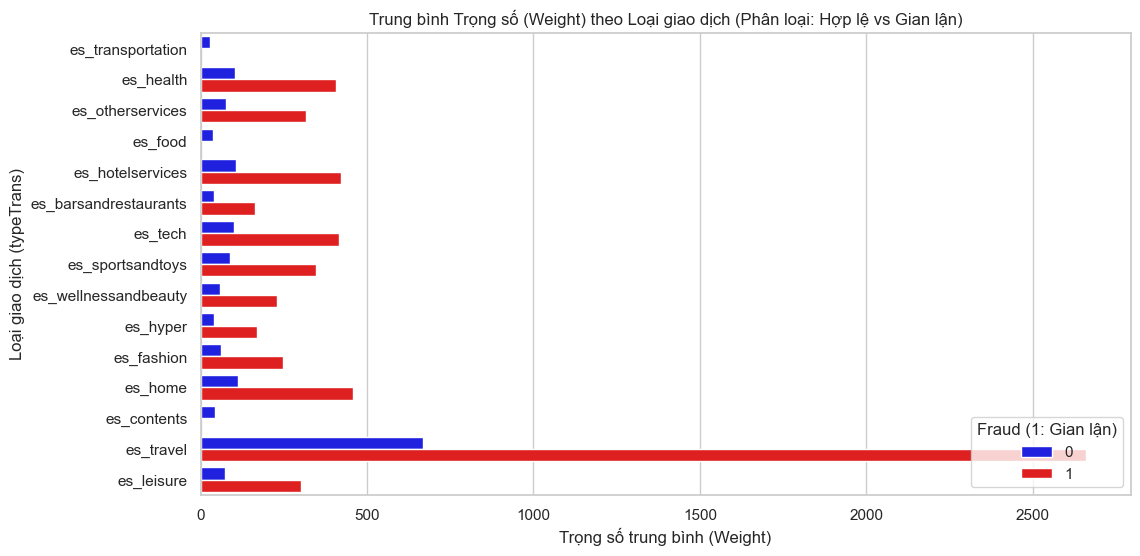

=> NHẬN XÉT: Biểu đồ cho thấy sự khác biệt rõ rệt. Khi một giao dịch là Gian lận (màu đỏ), mức Weight trung bình của nó luôn cao hơn hẳn hoặc bất thường so với mức Weight của giao dịch hợp lệ (màu xanh) ở cùng một loại hình kinh doanh. Đặc biệt là nhóm Du lịch (travel) hoặc Thể thao (sports_and_toys).


In [59]:
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ thể hiện trung bình Weight theo typeTrans, phân biệt bằng fraud
# Lọc bỏ một số giao dịch hợp lệ có Weight quá lớn gây nhiễu biểu đồ (để dễ nhìn)
sns.barplot(data=df1, x='Weight', y='typeTrans', hue='fraud', palette=['blue', 'red'], errorbar=None)

plt.title('Trung bình Trọng số (Weight) theo Loại giao dịch (Phân loại: Hợp lệ vs Gian lận)')
plt.xlabel('Trọng số trung bình (Weight)')
plt.ylabel('Loại giao dịch (typeTrans)')
plt.legend(title='Fraud (1: Gian lận)', loc='lower right')

plt.show()

print("=> NHẬN XÉT: Biểu đồ cho thấy sự khác biệt rõ rệt. Khi một giao dịch là Gian lận (màu đỏ), mức Weight trung bình của nó luôn cao hơn hẳn hoặc bất thường so với mức Weight của giao dịch hợp lệ (màu xanh) ở cùng một loại hình kinh doanh. Đặc biệt là nhóm Du lịch (travel) hoặc Thể thao (sports_and_toys).")

### 1.5. Phân tích tương quan mở rộng (Extended Correlation Analysis)

Để có cái nhìn toàn diện hơn, chúng ta sẽ mã hóa các biến phân loại và đưa chúng vào ma trận tương quan.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Tạo bản sao để tính toán tương quan
df_corr = df.copy()

# Encode các cột phân loại để đưa vào ma trận tương quan
le = LabelEncoder()
for col in ['age', 'gender', 'category']:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# Tính ma trận tương quan giữa các biến quan trọng
corr = df_corr[['age', 'gender', 'category', 'amount', 'fraud']].corr()

# Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan mở rộng (Age, Gender, Category, Amount, Fraud)')
plt.show()

### 1.6. Biểu đồ tròn (Pie Charts) cho Fraud và Category

Trực quan hóa tỷ lệ phần trăm để thấy rõ sự mất cân bằng dữ liệu và phân phối các ngành hàng.

In [ ]:
# Thiết lập biểu đồ
plt.figure(figsize=(16, 8))

# 1. Biểu đồ tròn cho Fraud
plt.subplot(1, 2, 1)
fraud_counts = df['fraud'].value_counts()
plt.pie(fraud_counts, labels=['Hợp lệ (0)', 'Gian lận (1)'], autopct='%1.1f%%', 
        startangle=140, colors=['#66b3ff','#ff9999'], explode=(0, 0.1))
plt.title('Tỷ lệ Giao dịch Hợp lệ vs Gian lận', fontsize=14)

# 2. Biểu đồ tròn cho Category (Top 7 và Others)
plt.subplot(1, 2, 2)
category_counts = df['category'].value_counts()
top_n = 7
top_categories = category_counts[:top_n]
others = pd.Series({'Khác': category_counts[top_n:].sum()})
combined_categories = pd.concat([top_categories, others])

plt.pie(combined_categories, labels=combined_categories.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'))
plt.title(f'Phân phối Category (Top {top_n} & Khác)', fontsize=14)

plt.tight_layout()
plt.show()